In [1]:
import pandas as pd
import numpy as np

In [2]:
df_test = pd.read_csv('datasets/real data/interactions_by_msoa_pair_and_time_2019_directional.csv')

df_test.head()

,origin_msoa11cd,destination_msoa11cd,hour,flow_sum
0,E02000001,E02000001,0,520
1,E02000192,E02000001,0,13
2,E02000193,E02000001,0,20
3,E02000371,E02000001,0,85
4,E02000575,E02000001,0,33


In [3]:
import geopandas as gpd

#load data
path= "datasets/real data/MSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3_2022_-5342298291295739459.zip"
msoas = gpd.read_file(path)


msoas = msoas.to_crs(epsg=6933)
msoas.head()

msoas['area_km2'] = msoas.geometry.area / 1e6

area = msoas[['MSOA11CD', 'area_km2']].copy()


In [4]:
msoas.head(400)

,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,area_km2
0,E02000001,City of London 001,City of London 001,532378,181354,-0.093570,51.5156,7e1c3fbc-cc47-4e16-a505-d89e93921c28,"POLYGON ((-9338.505 5737960.092, -9308.083 573...",2.907269
1,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,548267,189693,0.138759,51.5866,9f32701c-7edc-4f73-b8c2-a1afac813fbb,"POLYGON ((14288.183 5743840.3, 14285.824 57438...",2.166595
2,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,548259,188522,0.138150,51.5761,7687f18e-6c8e-4afb-9c98-a9e633e00dd6,"POLYGON ((14533.356 5742743.762, 14316.827 574...",2.143995
3,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,551004,186418,0.176830,51.5564,67259638-dce5-461c-82f7-8fbac8335b66,"POLYGON ((17857.76 5741283.861, 17753.335 5741...",2.491928
4,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,548733,186827,0.144269,51.5607,dadad0f1-384f-4686-9535-5026812db2a9,"POLYGON ((14461.177 5741545.365, 14545.818 574...",1.186290
...,...,...,...,...,...,...,...,...,...,...
395,E02000411,Haringey 015,Haringey 015,534641,189817,-0.057740,51.5911,469ad459-267c-45c3-aea1-b87ae19ce64a,"POLYGON ((-5136.209 5744267.854, -5034.976 574...",1.384605
396,E02000412,Haringey 016,Haringey 016,531073,189949,-0.109170,51.5932,d87c98c7-e490-4482-bb9d-702e36676a78,"POLYGON ((-10154.895 5743823.501, -10358.341 5...",0.774950
397,E02000413,Haringey 017,Haringey 017,528079,189436,-0.152550,51.5892,6d4e3223-0e0d-40c6-96e5-0e22daf5cd4a,"POLYGON ((-14658.443 5743944.397, -14606.182 5...",1.224901
398,E02000414,Haringey 018,Haringey 018,533155,189773,-0.079200,51.5911,57b61786-ec27-44a8-b407-8d7203c8aeff,"POLYGON ((-7622.609 5743623.544, -7603.452 574...",0.412343


In [4]:
#cast to string
df_test['origin_msoa11cd'] = df_test['origin_msoa11cd'].astype(str)
df_test['destination_msoa11cd'] = df_test['destination_msoa11cd'].astype(str)
area['MSOA11CD'] = area['MSOA11CD'].astype(str)

df_merged = df_test.merge(area[['MSOA11CD', 'area_km2']], left_on='origin_msoa11cd', right_on='MSOA11CD', how='left')
df_merged.head()

,origin_msoa11cd,destination_msoa11cd,hour,flow_sum,MSOA11CD,area_km2
0,E02000001,E02000001,0,520,E02000001,2.907269
1,E02000192,E02000001,0,13,E02000192,0.432526
2,E02000193,E02000001,0,20,E02000193,1.086997
3,E02000371,E02000001,0,85,E02000371,0.996142
4,E02000575,E02000001,0,33,E02000575,0.930778


In [5]:
df_merged= df_merged.drop(columns=['MSOA11CD'])
#df_merged['area_km2'].sum()

In [6]:

# 1. Create integer index mapping for nodes

df_merged = df_merged [df_merged['destination_msoa11cd'].isin(df_merged['origin_msoa11cd'].unique())]


all_nodes = pd.concat([df_merged['origin_msoa11cd'], df_merged['destination_msoa11cd']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)


ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]


population = (df_merged.groupby('origin_msoa11cd')['flow_sum'].sum()).reset_index()
population= population.rename(columns= {'flow_sum' : 'total_populaiton'})
df_merged_pop = df_merged.merge(population, on='origin_msoa11cd', how='left')

total_flows = df_merged_pop.groupby(['origin_msoa11cd', 'destination_msoa11cd'])['flow_sum'].sum().reset_index()
total_flows= total_flows.rename(columns= {'flow_sum' : 'total_flow'})
df_merged_pop = df_merged_pop.merge(total_flows, on=['origin_msoa11cd', 'destination_msoa11cd'], how='left')





# 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_merged_pop.drop_duplicates('origin_msoa11cd')
                .set_index('origin_msoa11cd')['area_km2']
                .reindex(ordered_geoids)
                .fillna(0)
                .values) *  0.386


area_distr.sum()

607.5636324355117

In [9]:
df_merged_pop = df_merged_pop.drop(columns = ['hour', 'flow_sum'])
df_merged_pop = df_merged_pop.drop_duplicates()


In [11]:
import numpy as np
from scipy.sparse import coo_matrix


rows = df_merged_pop['origin_msoa11cd'].map(node_to_idx).values
cols = df_merged_pop['destination_msoa11cd'].map(node_to_idx).values

# 3. Compute weight = fraction of origin population that flows to destination
#    pop_flows / total_pop gives: "X% of node i's population goes to node j"
weights = (df_merged_pop['total_flow'] / df_merged_pop['total_populaiton']).values

# 4. Build sparse matrix
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
#graph = graph.tocsr()

weights
#df_merged_pop

array([4.81293660e-01, 1.46141215e-01, 6.30161165e-02, ...,
       4.84712901e-03, 5.83771162e-03, 3.16856781e-04])

In [10]:
import scipy.sparse as sp

# Assuming 'graph' is your csr_matrix
sp.save_npz('testing graphs/mobility_graph_london.npz', graph)

In [12]:
print("node_to_idx size:", len(node_to_idx))
print("unique geoid_o in df_merged_pop:", df_merged_pop['origin_msoa11cd'].nunique())
print("unique geoid_d in df_merged_pop:", df_merged_pop['destination_msoa11cd'].nunique())

# Find the offending node
in_idx_not_in_origins = set(node_to_idx.keys()) - set(df_merged_pop['origin_msoa11cd'].unique())
print("nodes in graph but not in origins:", in_idx_not_in_origins)

node_to_idx size: 983
unique geoid_o in df_merged_pop: 983
unique geoid_d in df_merged_pop: 983
nodes in graph but not in origins: set()


In [13]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [15]:
from scipy.linalg import eig

def generate_data(input_graph,input_area_distr, recovery_rate, population, mobility_rate = 1,):
    graph = input_graph
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1




    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

     # --- diagnostics ---
    print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    print("eff_population NaNs:", np.isnan(eff_population).sum())
    print("population NaNs:", np.isnan(population).sum())
    print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius


population = (df_merged_pop.drop_duplicates('origin_msoa11cd')
                           .set_index('origin_msoa11cd')['total_populaiton']
                           .reindex(ordered_geoids)
                           .fillna(0)
                           .astype(float)
                           .values)
threshold = generate_data(graph, area_distr, 1, population, 1)




area_distr NaNs: 0 zeros: 0
eff_population NaNs: 0
population NaNs: 0
matrix_m NaNs: 0 Infs: 0
1.9341557049910643
0.5170214566591059


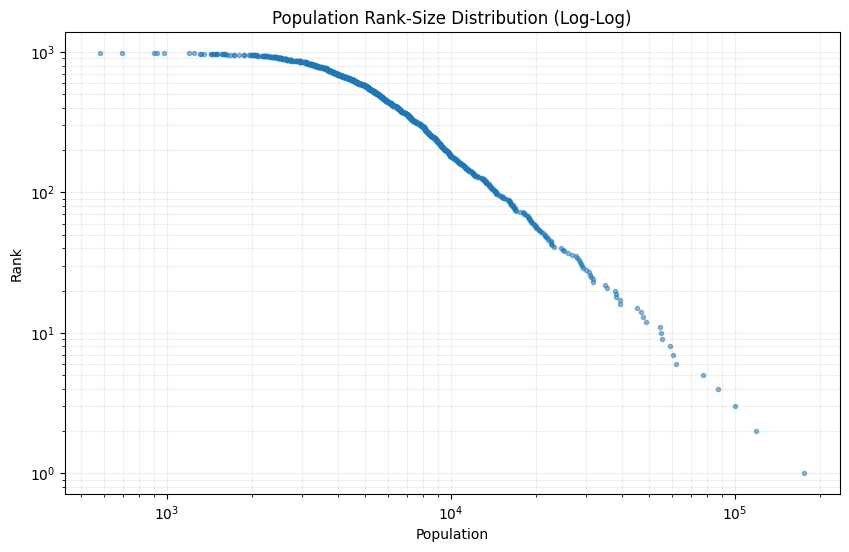

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Sort population from largest to smallest
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_pop, ranks, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.ylabel("Rank")
plt.xlabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

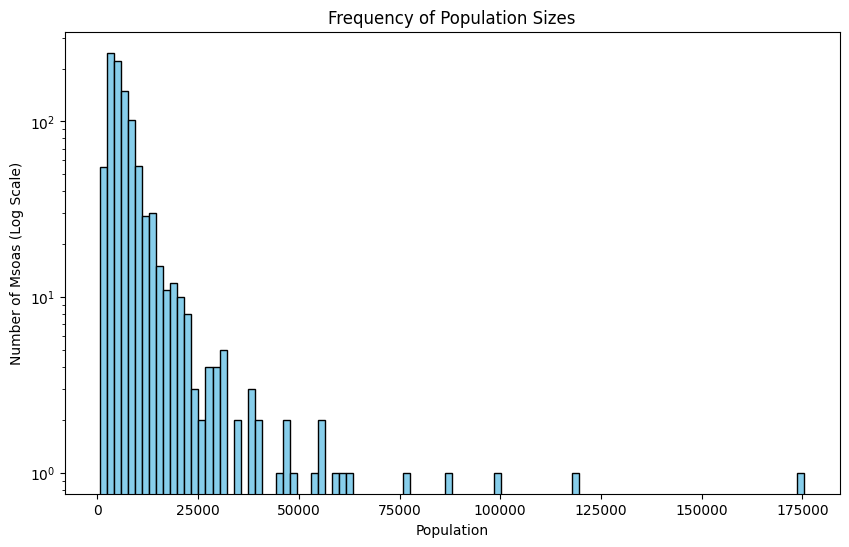

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Msoas (Log Scale)")
plt.show()

In [19]:
population.max()

175502.0

In [40]:
np.savez_compressed('testing graphs/mobility_metadata_real.npz',
                    population=population)

In [43]:

import torch
from torch_geometric.data import Data
import numpy as np
import os



edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

# 2. edge_attr: Shape [num_edges, 1], type float32
edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

# 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
node_features = np.column_stack((population, position_array))
x = torch.tensor(node_features, dtype=torch.float32)

# 4. y (Target label): Shape [1], type float32
y = torch.tensor([threshold], dtype=torch.float32)

# --- Construct PyG Data Object ---
data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Append to our list
pyg_graph = data_obj

save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/real_graph.pt'

torch.save(pyg_graph, save_path)


